# 06 — Executive Analytical Synthesis and Creator-Strategy Comparison (Day 3C)

## 1. Objective and decision questions

**Primary objective:** what does the verified multimodal evidence reveal about divergence
between TALA's official quality/responsibility claims and externally observable customer
experience?

**Secondary objective (professor feedback):** since TALA is prioritising a creator-led
strategy, how does its creator/partnership strategy differ from Adanola, Girlfriend
Collective and Oner Active across platforms -- what can TALA learn, and what defensible
moat hypotheses emerge?

This notebook uses **only existing, already-verified repository outputs** -- no new
collection, no external API calls, no engagement prediction, no causal inference, no
manual labelling. See `CLAUDE.md` §9 and `docs/project_charter.md` for the binding scope.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_columns", 30)

TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
print("Project root:", PROJECT_ROOT)

Project root: D:\MAS Assignment\tala-multimodal-ai


## 2. Data sources and boundaries

Inputs (all already verified in Day 1-3B):
- `data/processed/fusion/claim_evidence_units.csv`, `claim_fusion_results.csv`,
  `fusion_configuration_results.csv`, `fusion_sensitivity_results.csv`
- `data/processed/official_claim_features.csv`, `claim_multimodal_evidence_candidates.csv`
- `data/processed/creator_multimodal_features.csv`, `platform_strategy_features.csv`

Known evidence boundaries carried forward from Day 2/3A/3B (see
`docs/creator_strategy_comparison.md` for the full list):
- Creator evidence is overwhelmingly YouTube-based (60/61 verified records); 1 TikTok record.
- Creator records were collected via a targeted evidence-recovery process, not a
  statistically representative sample.
- Cross-platform creator-**performance** comparison is not permitted; engagement prediction
  is out of scope.
- Partnership/intent labels are automated, evidence-gated classifications, not
  human-labelled ground truth.

In [2]:
units = pd.read_csv(PROJECT_ROOT / "data/processed/fusion/claim_evidence_units.csv")
fusion = pd.read_csv(PROJECT_ROOT / "data/processed/fusion/claim_fusion_results.csv")
creators = pd.read_csv(PROJECT_ROOT / "data/processed/creator_multimodal_features.csv")
platform = pd.read_csv(PROJECT_ROOT / "data/processed/platform_strategy_features.csv")
print("claim_evidence_units:", units.shape)
print("claim_fusion_results:", fusion.shape)
print("creator_multimodal_features:", creators.shape, "| brands:", creators['brand'].value_counts().to_dict())
print("platform_strategy_features:", platform.shape)

claim_evidence_units: (119, 29)
claim_fusion_results: (37, 21)
creator_multimodal_features: (61, 102) | brands: {'TALA': 24, 'Adanola': 16, 'Girlfriend Collective': 13, 'Oner Active': 8}
platform_strategy_features: (31, 21)


## 3. Claim-level synthesis

The authoritative, claim-level synthesis table joining Day 3A fusion labels to
evidence-unit counts by modality and role, for all 37 TALA claims.

In [3]:
import subprocess
subprocess.run([sys.executable, str(PROJECT_ROOT / "scripts" / "build_analytical_synthesis.py")], check=True)
subprocess.run([sys.executable, str(PROJECT_ROOT / "scripts" / "build_mixed_claim_themes.py")], check=True)

master = pd.read_csv(TABLES / "analytical_synthesis_claim_master.csv")
assert len(master) == 37 and master["claim_id"].nunique() == 37
master[["claim_id", "claim_category", "production_fusion_label", "fusion_confidence",
        "supporting_evidence_count", "challenging_evidence_count", "independent_evidence_count"]].head(10)

,claim_id,claim_category,production_fusion_label,fusion_confidence,supporting_evidence_count,challenging_evidence_count,independent_evidence_count
0,c_OC_0002_00,labour,insufficient_evidence,0.50,0,0,0
1,c_OC_0002_01,labour,insufficient_evidence,0.50,0,0,0
2,c_OC_0003_01,materials,aligned,0.70,2,0,2
3,c_OC_0004_00,materials,aligned,0.75,3,0,3
4,c_OC_0005_00,labour,insufficient_evidence,0.50,0,0,0
5,c_OC_0005_01,labour,insufficient_evidence,0.50,0,0,0
6,c_OC_0007_00,labour,insufficient_evidence,0.50,0,0,0
7,c_OC_0007_01,labour,insufficient_evidence,0.50,0,0,0
8,c_OC_0008_00,labour,insufficient_evidence,0.50,0,0,0
9,c_OC_0008_01,labour,insufficient_evidence,0.50,0,0,0


## 4. Fusion-label distribution

,automated_label,n_claims,pct_of_total,section,claim_category
0,aligned,14,37.8,overall_label_distribution,NaN
1,partially_aligned,0,0.0,overall_label_distribution,NaN
2,mixed,5,13.5,overall_label_distribution,NaN
3,divergent,0,0.0,overall_label_distribution,NaN
4,insufficient_evidence,18,48.6,overall_label_distribution,NaN


automated_label,aligned,divergent,insufficient_evidence,mixed,partially_aligned
claim_category,,,,,
circularity,1,0,0,0,0
emissions,0,0,1,0,0
labour,0,0,14,0,0
manufacturing,8,0,0,0,0
materials,3,0,0,4,0
other,2,0,2,1,0
packaging,0,0,1,0,0


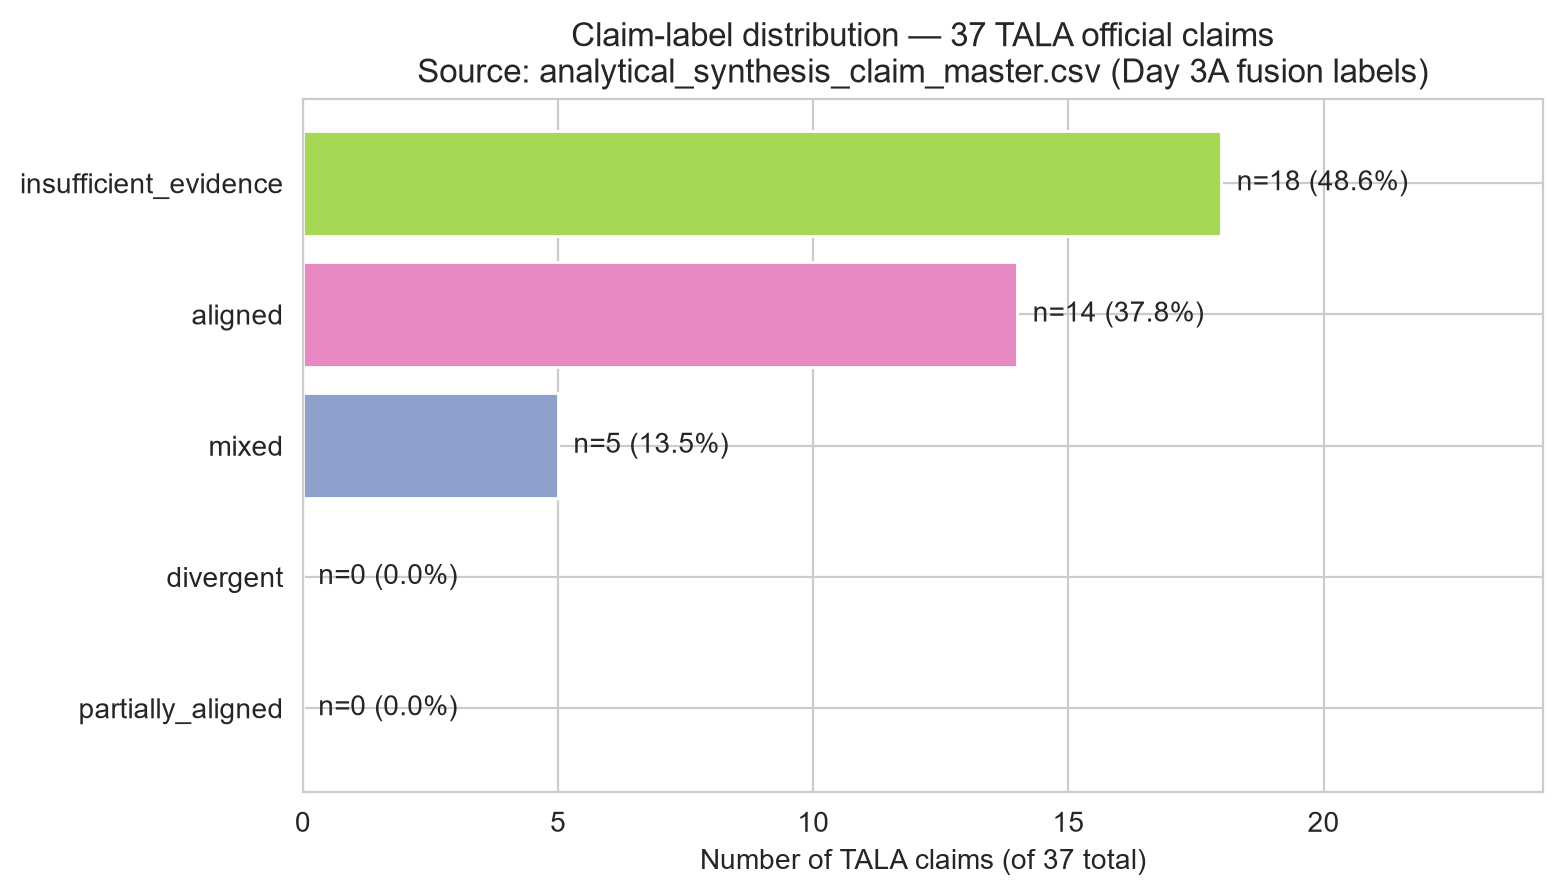

In [4]:
label_summary = pd.read_csv(TABLES / "claim_label_summary.csv")
display(label_summary[label_summary["section"] == "overall_label_distribution"])
display(label_summary[label_summary["section"] == "by_claim_category"].pivot(
    index="claim_category", columns="automated_label", values="n_claims"))
from IPython.display import Image
Image(filename=str(FIGURES / "claim_label_distribution.png"))

## 5. Mixed-claim deep dive

Every claim RECORD labelled `mixed` -- both supporting and challenging evidence exist; the
narrative explains the conflict rather than forcing a binary conclusion. **Record-level
vs. theme-level:** five claim records were classified as mixed, but they consolidate into
two underlying strategic tensions (deterministic text-match grouping, not five independent
areas of contradiction).

In [5]:
mixed_dd = pd.read_csv(TABLES / "mixed_claim_deep_dive.csv")
mixed_themes = pd.read_csv(TABLES / "mixed_claim_theme_summary.csv")
print(f"Claim-record level: {len(mixed_dd)}/{len(master)} mixed")
print(f"Theme level: {len(mixed_themes)} distinct mixed themes")
mixed_dd[["claim_id", "theme_id", "exact_official_claim", "supporting_evidence_count",
          "challenging_evidence_count", "why_evidence_conflicts"]]

Claim-record level: 5/37 mixed
Theme level: 2 distinct mixed themes


,claim_id,theme_id,exact_official_claim,supporting_evidence_count,challenging_evidence_count,why_evidence_conflicts
0,c_OC_0010_00,theme_01,"/ ABOUT US\nEstablished in 2019, TALA’s mission is to bring you consciously-made, active-inspire...",2,1,Supporting evidence draws on official/self-reported and some independent sources while challengi...
1,c_OC_0014_10,theme_02,"During product development meetings and trips, the TALA product team collaborates with the tier ...",2,1,Supporting evidence draws on official/self-reported and some independent sources while challengi...
2,c_OC_0016_10,theme_02,"During product development meetings and trips, the TALA product team collaborates with the tier ...",2,1,Supporting evidence draws on official/self-reported and some independent sources while challengi...
3,c_OC_0017_10,theme_02,"During product development meetings and trips, the TALA product team collaborates with the tier ...",2,1,Supporting evidence draws on official/self-reported and some independent sources while challengi...
4,c_OC_0023_10,theme_02,"During product development meetings and trips, the TALA product team collaborates with the tier ...",2,1,Supporting evidence draws on official/self-reported and some independent sources while challengi...


In [6]:
mixed_themes[["theme_id", "theme_name", "claim_record_count", "claim_ids", "observed_tension"]]

,theme_id,theme_name,claim_record_count,claim_ids,observed_tension
0,theme_01,Brand mission / conscious-value proposition,1,c_OC_0010_00,TALA's conscious-value brand-mission statement is both supported and challenged by evidence in t...
1,theme_02,Tier-3 supplier / material-innovation collaboration,4,c_OC_0014_10;c_OC_0016_10;c_OC_0017_10;c_OC_0023_10,"The claim of active, ongoing tier-3 supplier collaboration on fabric innovation is both supporte..."


## 6. Insufficient-evidence analysis

Insufficient evidence is a **gap finding**, never interpreted as contradiction.

In [7]:
insuff = pd.read_csv(TABLES / "insufficient_evidence_analysis.csv")
print(f"{len(insuff)} insufficient-evidence claims (of {len(master)} total)")
insuff["reason_label"].value_counts()

18 insufficient-evidence claims (of 37 total)


reason_label
no_public_corroboration_found    18
Name: count, dtype: int64

In [8]:
aligned_ex = pd.read_csv(TABLES / "aligned_claim_examples.csv")
aligned_ex[["claim_id", "claim_text", "selection_criteria", "alignment_basis"]]

,claim_id,claim_text,selection_criteria,alignment_basis
0,c_OC_0004_00,"With innovative fabrics, sweat-wicking technology and carefully considered fits, our activewear ...",supporting_evidence_count>=2; label stable across weighting scenarios (not sensitive_to_weights)...,independent evidence contributes
1,c_OC_0024_00,"With innovative fabrics, sweat-wicking technology and carefully considered fits, our activewear ...",supporting_evidence_count>=2; label stable across weighting scenarios (not sensitive_to_weights)...,independent evidence contributes
2,c_OC_0003_01,We responsibly source and ethically produce our collections using recycled and low-impact materi...,supporting_evidence_count>=2; label stable across weighting scenarios (not sensitive_to_weights)...,independent evidence contributes


## 7. Modality contribution

Comparing the four fusion configurations (text-only -> text+image -> text+image+video ->
full multimodal) shows label **stability** with confidence **drift** as modalities are added.

,configuration,modalities,claims_processed,claims_with_sufficient_evidence,aligned,partially_aligned,mixed,divergent,insufficient_evidence,mean_confidence,evidence_coverage_pct,claims_changed_from_previous,confidence_delta_from_text_only,section,modality,n_units,n_supports,n_challenges,n_context_only,n_gate_passed,metric,value,denominator
0,text_only,text,37.0,19.0,14.0,0.0,5.0,0.0,18.0,0.5378,100.0,0.0,0.0000,configuration_comparison,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,text_image,text;image,37.0,19.0,14.0,0.0,5.0,0.0,18.0,0.5419,100.0,0.0,0.0041,configuration_comparison,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,text_image_video,text;image;video,37.0,19.0,14.0,0.0,5.0,0.0,18.0,0.5419,100.0,0.0,0.0041,configuration_comparison,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,text_image_video_reference,text;image;video;reference,37.0,19.0,14.0,0.0,5.0,0.0,18.0,0.5676,100.0,0.0,0.0298,configuration_comparison,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,configuration,modalities,claims_processed,claims_with_sufficient_evidence,aligned,partially_aligned,mixed,divergent,insufficient_evidence,mean_confidence,evidence_coverage_pct,claims_changed_from_previous,confidence_delta_from_text_only,section,modality,n_units,n_supports,n_challenges,n_context_only,n_gate_passed,metric,value,denominator
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cross_configuration_summary,NaN,NaN,NaN,NaN,NaN,NaN,claims_with_label_change_across_configurations,0,37.0
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cross_configuration_summary,NaN,NaN,NaN,NaN,NaN,NaN,claims_with_more_eligible_evidence_in_full_vs_text_only,16,37.0
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cross_configuration_summary,NaN,NaN,NaN,NaN,NaN,NaN,note,label distribution identical across all 4 configurations (14 aligned / 5 mixed / 18 insufficient...,NaN


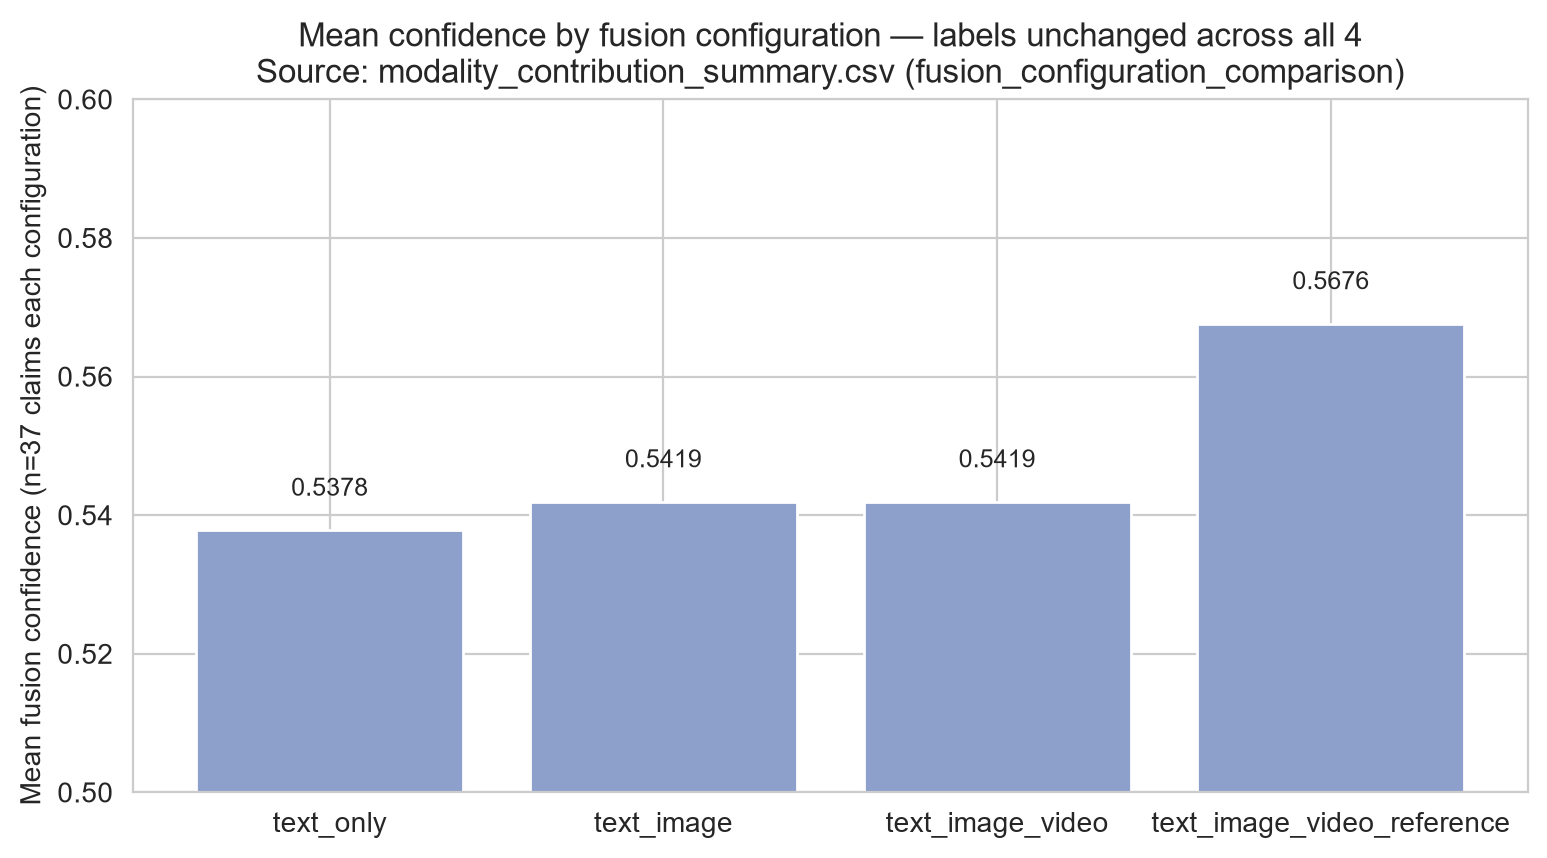

In [9]:
modality = pd.read_csv(TABLES / "modality_contribution_summary.csv")
display(modality[modality["section"] == "configuration_comparison"])
display(modality[modality["section"] == "cross_configuration_summary"])
Image(filename=str(FIGURES / "modality_confidence_contribution.png"))

In [10]:
gap = pd.read_csv(TABLES / "evidence_gap_by_category.csv")
gap

,claim_category,total_claims,claims_with_independent_evidence,claims_with_only_self_reported_evidence,claims_with_customer_evidence,claims_with_image_evidence,claims_with_video_evidence,claims_with_reference_evidence,claims_with_zero_usable_evidence_beyond_claim,dominant_missing_evidence_type
0,circularity,1,1,0,1,0,0,1,0,image
1,emissions,1,0,0,0,0,0,0,1,customer/independent
2,labour,14,0,0,0,0,0,0,14,customer/independent
3,manufacturing,8,8,0,8,0,0,8,0,image
4,materials,7,7,0,7,3,7,7,0,image
5,other,5,3,0,3,0,0,0,0,image
6,packaging,1,0,0,0,0,0,0,1,customer/independent


## 8. Creator evidence coverage (Part B)

**Analytical scope of Part B: cross-brand YouTube creator-strategy comparison combined
with an official-channel platform comparison.** 60 of 61 verified creator records are
YouTube, 1 is TikTok, 0 are Instagram -- this is not a comprehensive cross-platform
creator comparison, not an Instagram creator analysis, and not a representative sample of
each brand's complete creator strategy.

In [11]:
subprocess.run([sys.executable, str(PROJECT_ROOT / "scripts" / "build_creator_strategy_comparison.py")], check=True)
coverage = pd.read_csv(TABLES / "creator_strategy_evidence_coverage.csv")
coverage

,brand,verified_creator_records,unique_creators_or_channels,platforms_represented_creator,official_platform_records,platforms_represented_official,records_with_verified_partnership_type,records_with_classified_intent,records_with_usable_media,records_with_engagement_metrics,coverage_limitation,analysis_permitted,analysis_prohibited
0,TALA,24,21,youtube,3,tiktok;website;youtube,22,24,24,24,Creator sample overwhelmingly YouTube across the whole verified corpus (60/61 records); this bra...,within-platform (YouTube) creator strategy comparison; official cross-platform comparison using ...,cross-platform creator-performance comparison; engagement prediction; causal claims
1,Adanola,16,11,tiktok;youtube,10,website,16,16,15,15,Creator sample overwhelmingly YouTube across the whole verified corpus (60/61 records); this bra...,within-platform (YouTube) creator strategy comparison; official cross-platform comparison using ...,cross-platform creator-performance comparison; engagement prediction; causal claims
2,Girlfriend Collective,13,13,youtube,9,website,13,13,13,13,Creator sample overwhelmingly YouTube across the whole verified corpus (60/61 records); this bra...,within-platform (YouTube) creator strategy comparison; official cross-platform comparison using ...,cross-platform creator-performance comparison; engagement prediction; causal claims
3,Oner Active,8,7,youtube,9,website,8,8,8,8,Creator sample overwhelmingly YouTube across the whole verified corpus (60/61 records); this bra...,within-platform (YouTube) creator strategy comparison; official cross-platform comparison using ...,cross-platform creator-performance comparison; engagement prediction; causal claims


## 9. Partnership comparison

partnership_type,affiliate,ambassador,founder_or_employee,gifted,organic,paid_sponsorship,unclear
brand,,,,,,,
Adanola,25.0,0.0,0.0,6.2,18.8,50.0,0.0
Girlfriend Collective,61.5,0.0,0.0,7.7,30.8,0.0,0.0
Oner Active,12.5,0.0,0.0,0.0,87.5,0.0,0.0
TALA,12.5,4.2,4.2,8.3,62.5,0.0,8.3


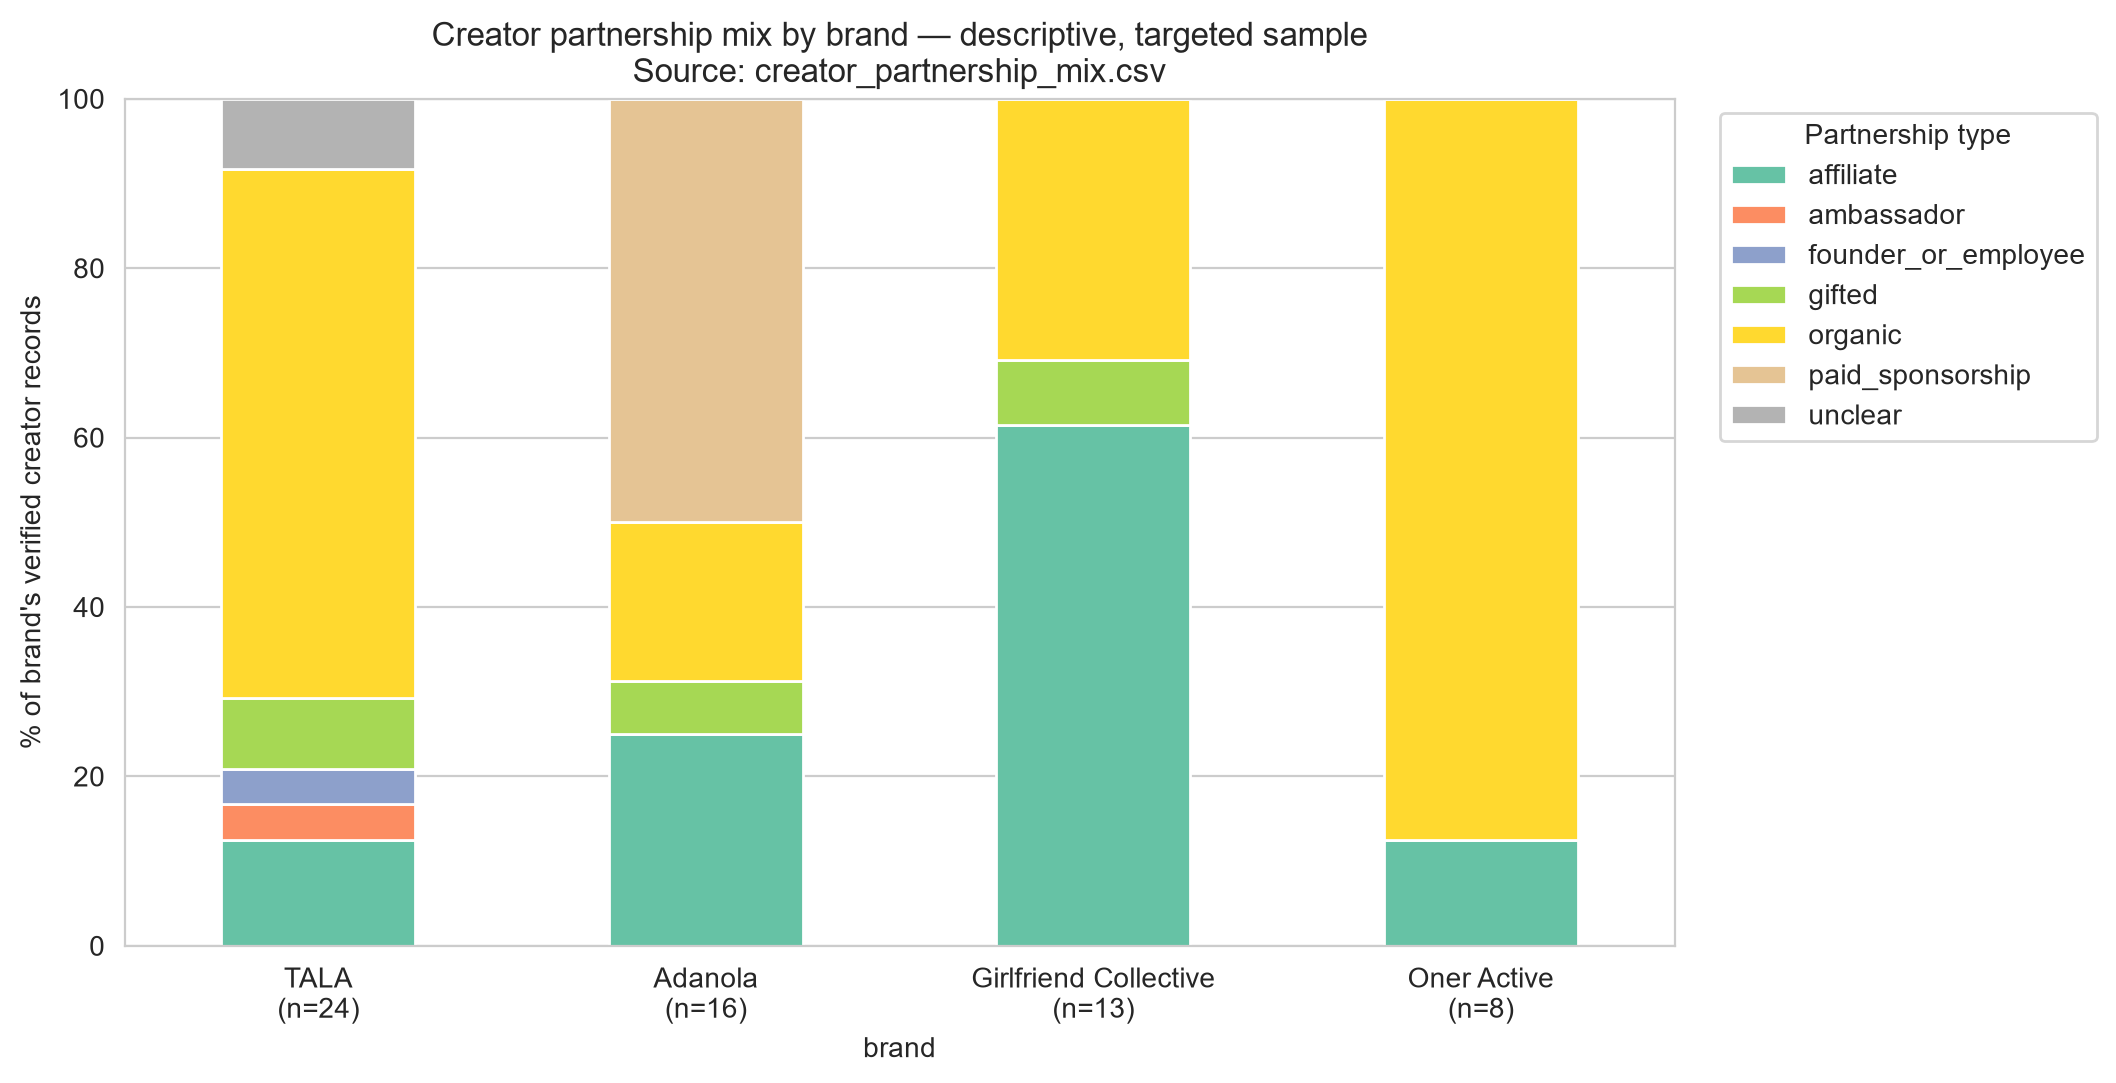

In [12]:
partnership_mix = pd.read_csv(TABLES / "creator_partnership_mix.csv")
display(partnership_mix.pivot(index="brand", columns="partnership_type", values="pct_within_brand"))
Image(filename=str(FIGURES / "creator_partnership_mix_by_brand.png"))

## 10. Content-intent comparison

content_intent,mixed,other,product_demonstration,responsibility,review,social_proof,unclear
brand,,,,,,,
Adanola,0.0,0.0,100.0,0.0,0.0,0.0,0.0
Girlfriend Collective,30.8,0.0,46.2,7.7,15.4,0.0,0.0
Oner Active,37.5,0.0,50.0,0.0,12.5,0.0,0.0
TALA,4.2,0.0,75.0,4.2,12.5,4.2,0.0


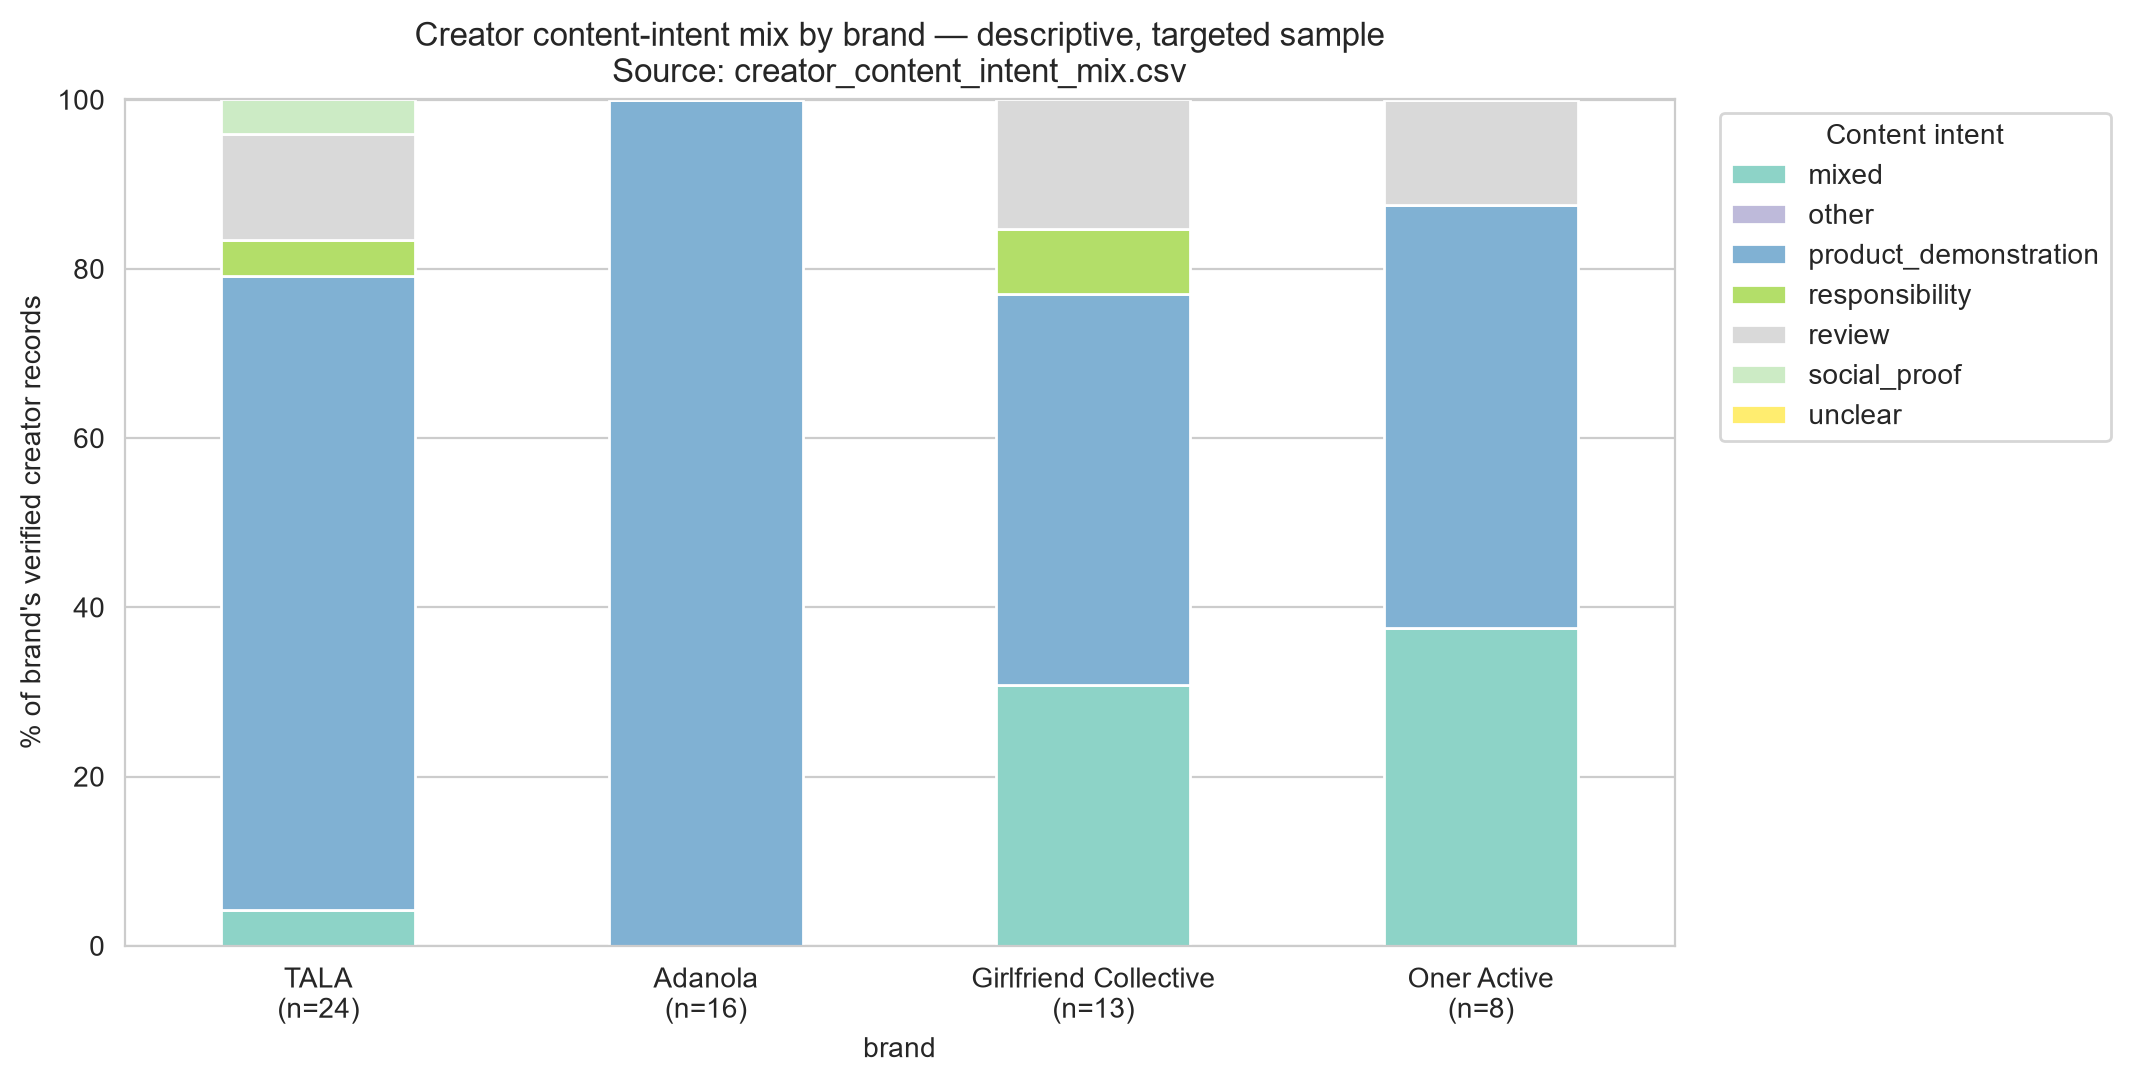

In [13]:
intent_mix = pd.read_csv(TABLES / "creator_content_intent_mix.csv")
display(intent_mix.pivot(index="brand", columns="content_intent", values="pct_within_brand"))
Image(filename=str(FIGURES / "creator_intent_mix_by_brand.png"))

## 11. Partnership x intent

The central question: **what job does each partnership type appear to perform**, not
which partnership performs best.

content_intent,mixed,other,product_demonstration,responsibility,review,social_proof,unclear
partnership_type,,,,,,,
affiliate,3,0,10,1,2,0,0
ambassador,0,0,0,0,0,1,0
founder_or_employee,0,0,1,0,0,0,0
gifted,1,0,3,0,0,0,0
organic,0,0,0,0,0,0,0
paid_sponsorship,0,0,8,0,0,0,0
unclear,0,0,1,1,0,0,0


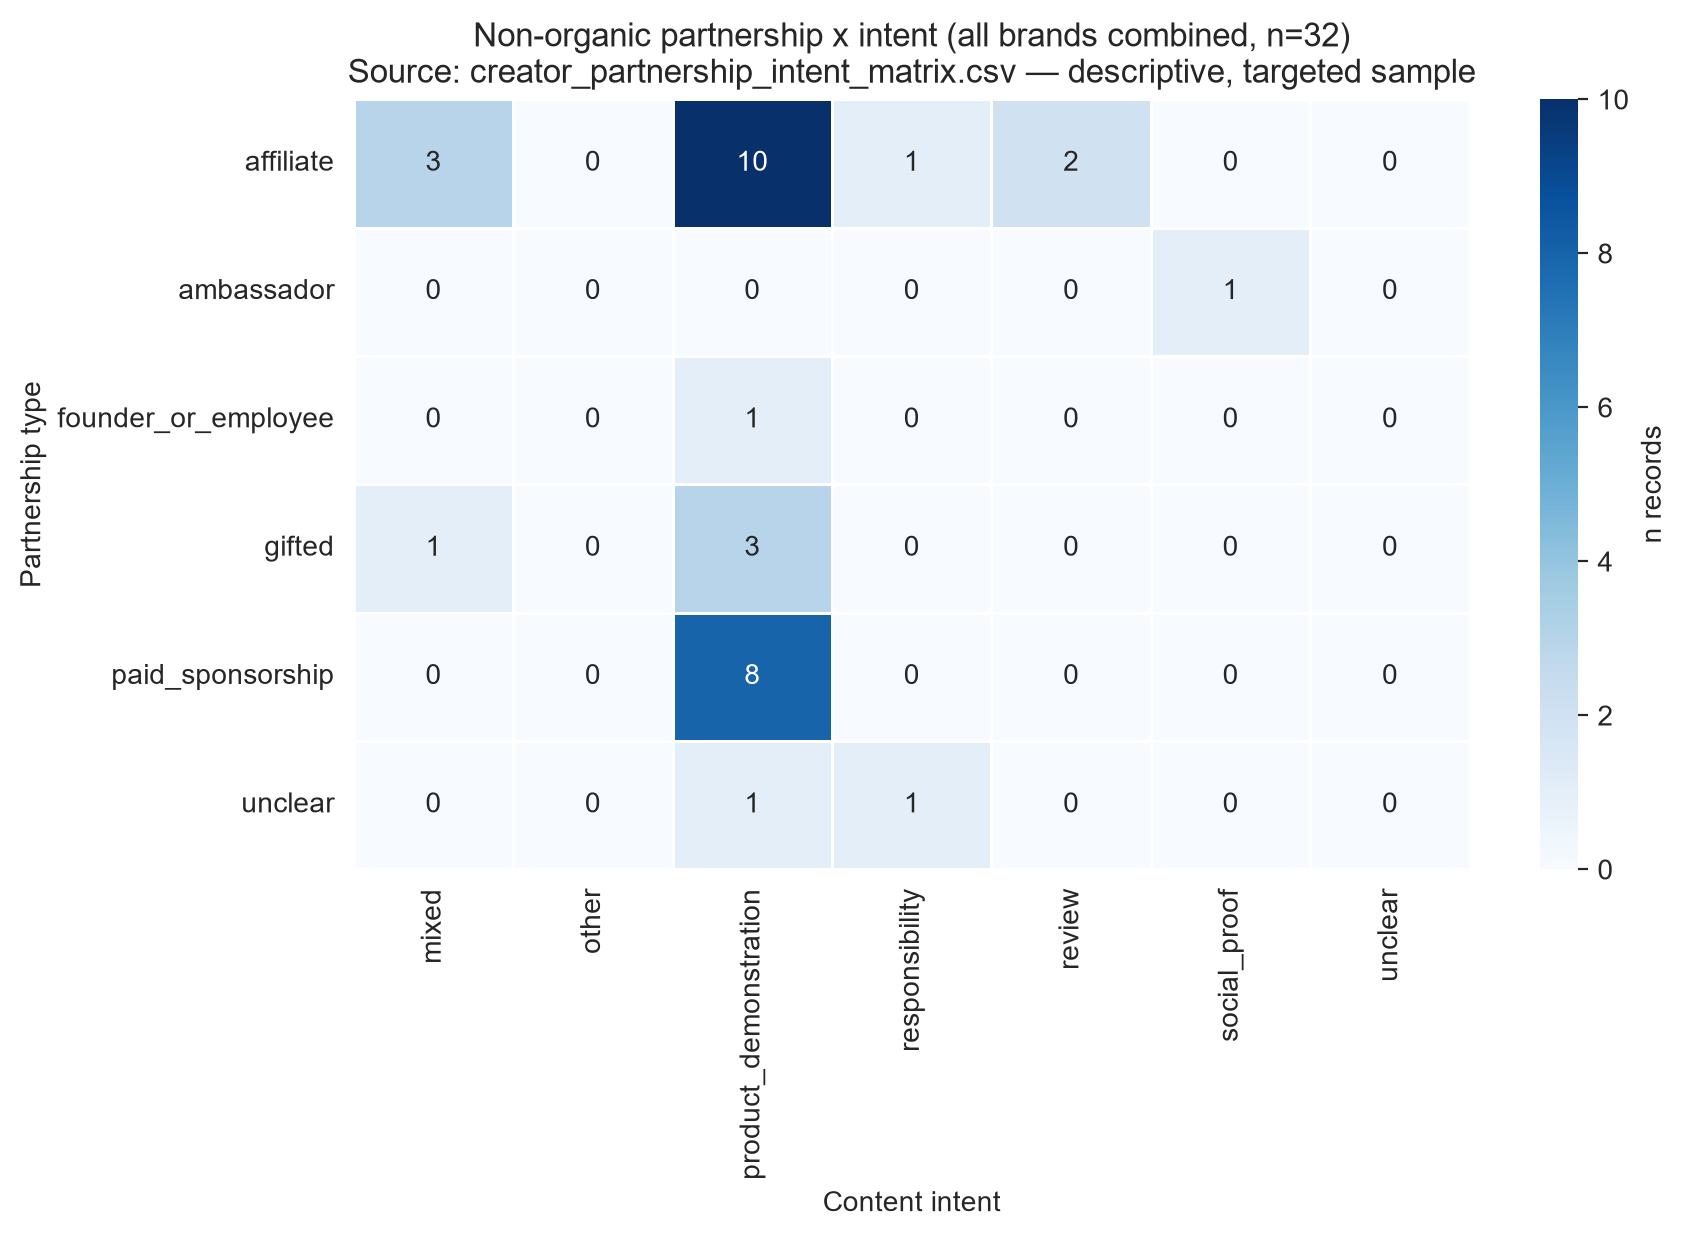

In [14]:
matrix = pd.read_csv(TABLES / "creator_partnership_intent_matrix.csv")
non_organic = matrix[matrix["scope"] == "non_organic_only"]
display(non_organic.pivot(index="partnership_type", columns="content_intent", values="count"))
Image(filename=str(FIGURES / "nonorganic_partnership_intent_matrix.png"))

## 12. Platform roles

In [15]:
platform_role = pd.read_csv(TABLES / "brand_platform_strategy_comparison.csv")
platform_role


,brand,platform,platform_present,observed_content_role,creator_led_vs_brand_led,product_demonstration_role,responsibility_communication_role,community_social_proof_role,commerce_or_affiliate_role,evidence_count,evidence_limitation
0,TALA,tiktok,True,brand_social:1,creator_led_confirmed:0/1,0,0,0,0,1,"Official-platform snapshot evidence only, no verified creator records for this platform/brand"
1,TALA,website,True,commerce_and_brand:1,creator_led_confirmed:0/1,0,1,0,1,1,"Official-platform snapshot evidence only, no verified creator records for this platform/brand"
2,TALA,youtube,True,brand_video:1,creator_led_confirmed:1/1,18,0,1,0,25,Creator-record evidence for this platform
3,Adanola,tiktok,True,no official_platform_features records,creator_records_observed:1,1,0,0,0,1,Creator-record evidence for this platform
4,Adanola,website,True,commerce_and_brand:10,creator_led_confirmed:3/10,0,2,0,10,10,"Official-platform snapshot evidence only, no verified creator records for this platform/brand"
5,Adanola,youtube,True,no official_platform_features records,creator_records_observed:15,15,0,0,0,15,Creator-record evidence for this platform
6,Girlfriend Collective,website,True,commerce_and_brand:9,creator_led_confirmed:1/9,0,8,0,9,9,"Official-platform snapshot evidence only, no verified creator records for this platform/brand"
7,Girlfriend Collective,youtube,True,no official_platform_features records,creator_records_observed:13,6,0,0,0,13,Creator-record evidence for this platform
8,Oner Active,website,True,commerce_and_brand:9,creator_led_confirmed:1/9,0,3,0,9,9,"Official-platform snapshot evidence only, no verified creator records for this platform/brand"
9,Oner Active,youtube,True,no official_platform_features records,creator_records_observed:8,4,0,0,0,8,Creator-record evidence for this platform


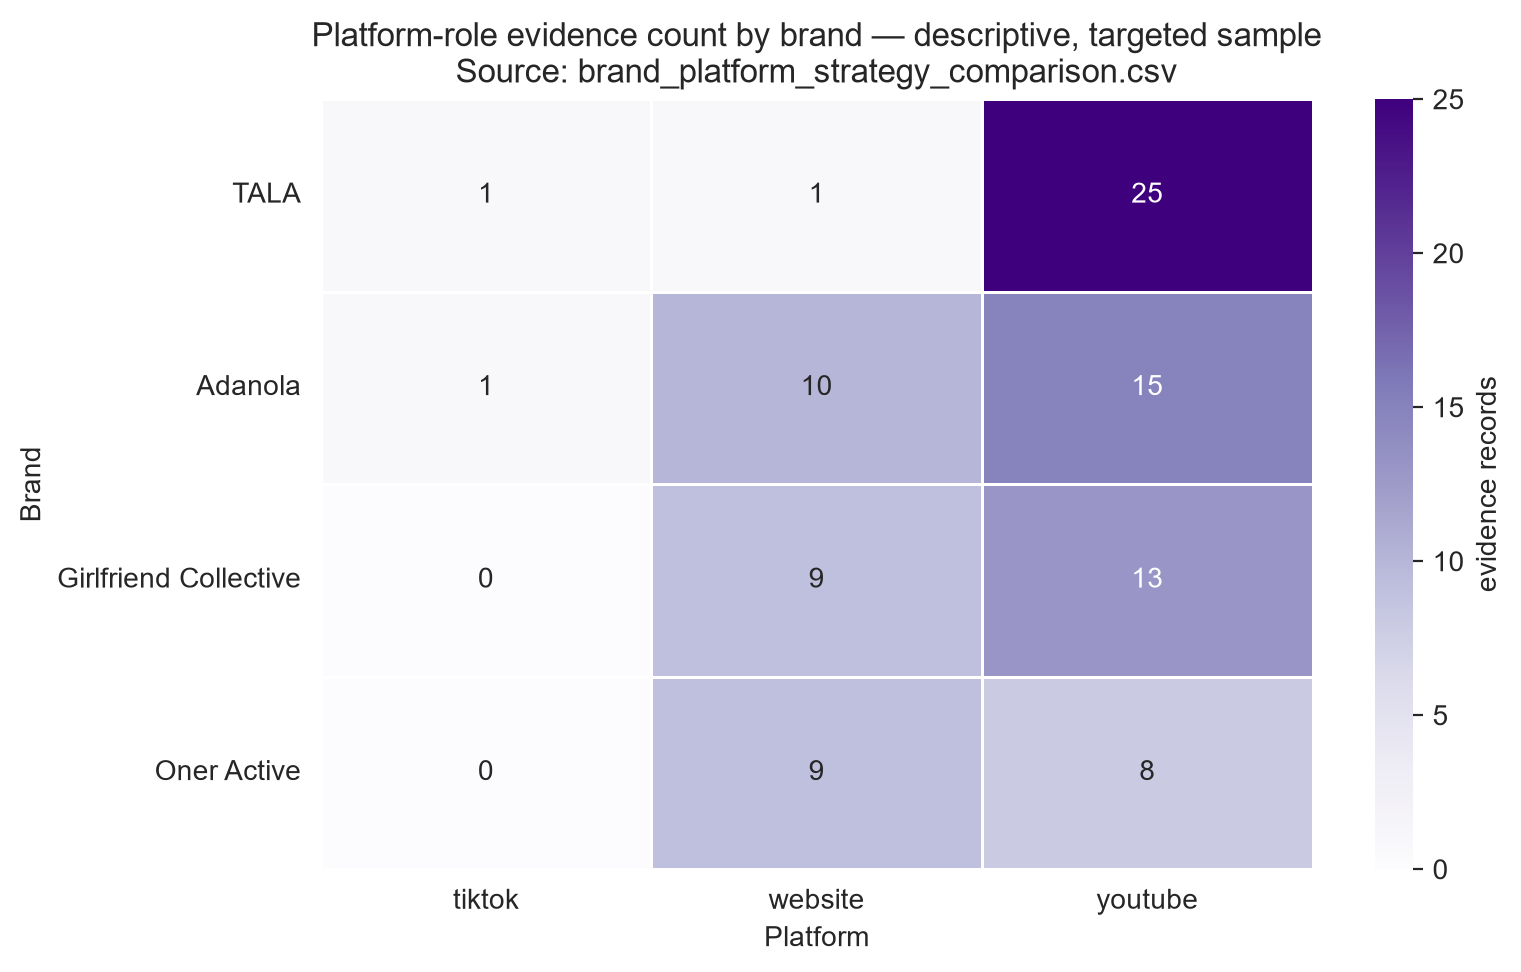

In [16]:
Image(filename=str(FIGURES / "brand_platform_strategy_matrix.png"))

## 13. Competitor lessons

In [17]:
subprocess.run([sys.executable, str(PROJECT_ROOT / "scripts" / "build_strategic_interpretation.py")], check=True)
lessons = pd.read_csv(TABLES / "tala_competitor_lessons.csv")
lessons[["lesson_id", "comparator_brand", "observed_competitor_practice", "lesson_category", "potential_tala_action"]]

,lesson_id,comparator_brand,observed_competitor_practice,lesson_category,potential_tala_action
0,lesson_01,Adanola,Adanola's paid-sponsorship and affiliate records (16 verified) carry product_demonstration inten...,test,"Pilot a small, contractually-scoped paid-sponsorship cohort for a single product line, with a pr..."
1,lesson_02,Girlfriend Collective,Girlfriend Collective shows the highest affiliate share among the four brands (61.5% of 13 verif...,test,"Trial an affiliate program for a defined creator tier, paired with review-intent content briefs,..."
2,lesson_03,Adanola,Adanola's verified creator sample shows no responsibility-intent content (0%) and no founder/emp...,avoid_copying_without_validation,Do not copy Adanola's apparent product-demonstration-only focus wholesale; TALA's existing respo...
3,lesson_04,TALA,TALA's own verified sample already includes founder_or_employee and ambassador partnership recor...,preserve,Preserve and deliberately expand founder/employee and ambassador-style creator relationships and...
4,lesson_05,Girlfriend Collective,Girlfriend Collective is the only competitor with verified responsibility-intent creator content...,test,Review whether TALA's existing responsibility-content creators could be briefed similarly to Gir...
5,lesson_06,Oner Active,"Oner Active's verified sample is small (n=8) and organic-leaning (87.5%), similar in direction t...",evidence_gap,No specific action recommended; corpus depth is too shallow to draw a comparator lesson from One...
6,lesson_07,Adanola,"No Instagram creator records are verified for any brand, including Adanola, despite Instagram be...",evidence_gap,"Flag as a collection gap, not a strategy conclusion: TALA cannot currently be benchmarked agains..."


## 14. Moat hypotheses

Status is always one of `plausible / weak / unsupported / contradicted` -- never
"proven moat".

In [18]:
moat = pd.read_csv(TABLES / "creator_moat_hypotheses.csv")
moat[["hypothesis_id", "brand", "observed_pattern", "verified_evidence_count", "status"]]

,hypothesis_id,brand,observed_pattern,verified_evidence_count,status
0,moat_01,TALA,TALA is the only brand in the corpus with verified founder_or_employee and ambassador creator re...,24,weak
1,moat_02,Girlfriend Collective,Girlfriend Collective shows the highest affiliate concentration among the four brands (61.5% of ...,8,weak
2,moat_03,Adanola,Adanola shows the most concentrated content-intent mix in the corpus (100% product_demonstration...,8,unsupported
3,moat_04,Oner Active,Oner Active's sample is the smallest (n=8) and shows no distinctive partnership or intent concen...,8,unsupported


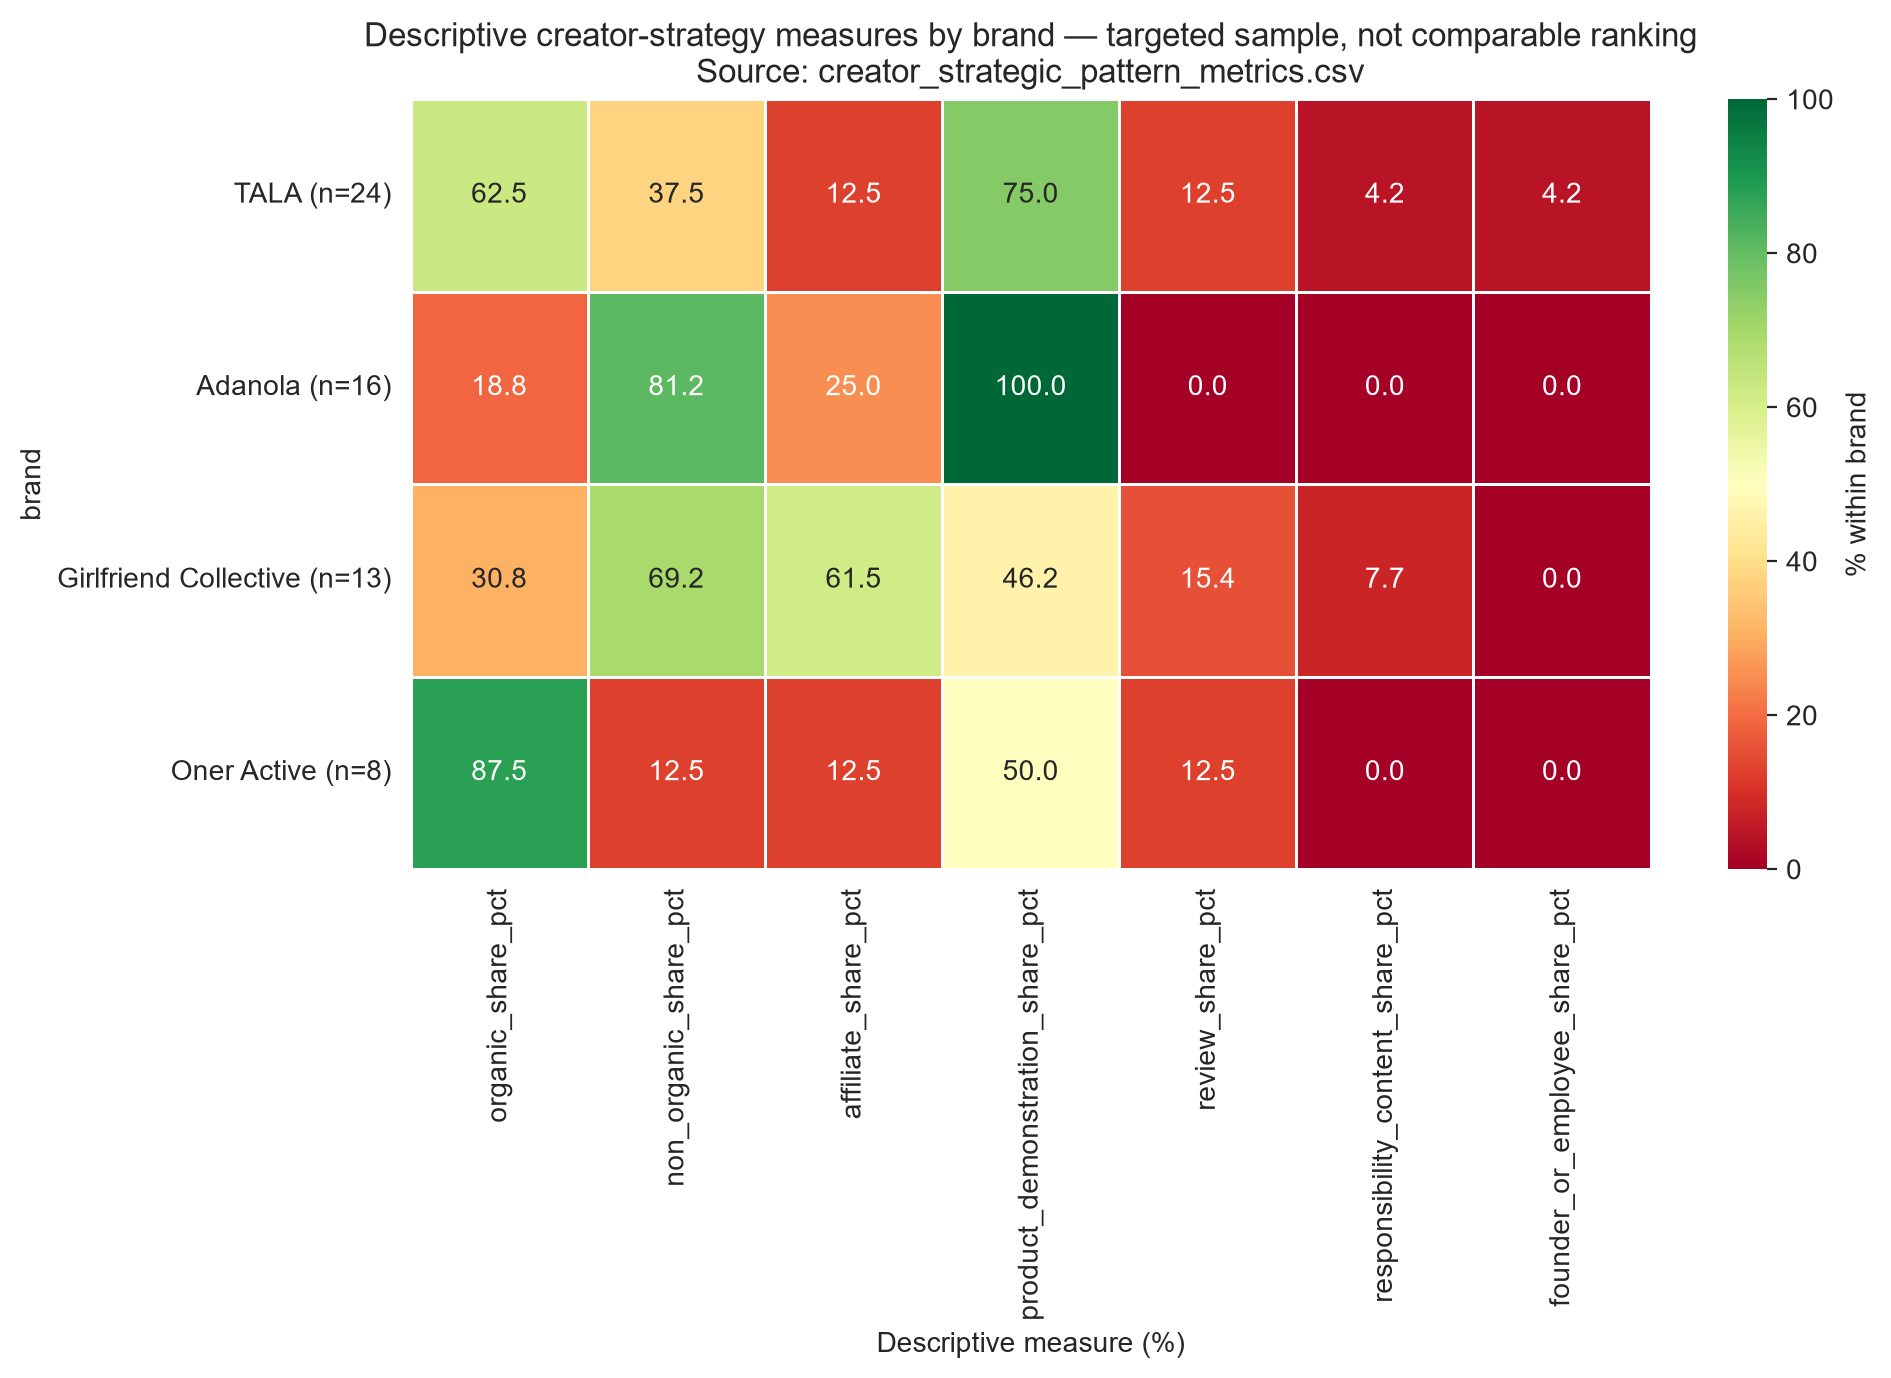

In [19]:
pattern_metrics = pd.read_csv(TABLES / "creator_strategic_pattern_metrics.csv")
pattern_metrics
Image(filename=str(FIGURES / "tala_competitor_strategy_heatmap.png"))

## 15. Executive findings

In [20]:
subprocess.run([sys.executable, str(PROJECT_ROOT / "scripts" / "build_executive_findings.py")], check=True)
findings = pd.read_csv(TABLES / "executive_finding_register.csv")
print(f"{len(findings)} executive findings")
findings[["finding_id", "analytical_stream", "finding", "observed_or_inferred"]]

10 executive findings


,finding_id,analytical_stream,finding,observed_or_inferred
0,F01,claim–experience divergence,The verified corpus places under half of TALA's 37 official claims in the 'aligned' automated fu...,observed
1,F02,claim–experience divergence,"Five of 37 claim records were classified as mixed, but they consolidate into 2 underlying strate...",observed
2,F03,evidence gaps,"Labour-category claims (14 of 37 claims, the largest category) show zero independent/customer ev...",observed
3,F04,modality contribution,"Adding image, video, and reference evidence changed mean fusion confidence but did not change an...",observed
4,F05,evidence gaps,No claim category has both zero image AND zero reference evidence simultaneously except labour a...,observed
5,F06,creator strategy,"Oner Active has the highest observed organic share, but its eight-record sample is too shallow f...",observed
6,F07,competitor learning,Adanola's verified creator content is the most content-intent-concentrated in the corpus (100% p...,observed
7,F08,moat hypothesis,A plausible-but-currently-weak moat hypothesis exists around TALA's founder/employee and ambassa...,hypothesis
8,F09,creator strategy,"No Instagram creator records are verified for any of the four brands in this corpus, and cross-p...",observed
9,F10,claim–experience divergence,"Two of TALA's seven claim categories (manufacturing, materials) have image, and in materials' ca...",observed


In [21]:
prof = pd.read_csv(TABLES / "professor_feedback_response.csv")
prof[["question_id", "question", "answer"]]

,question_id,question,answer
0,q1,How does TALA's creator-led strategy differ from competitors?,This is a cross-brand YouTube creator-strategy comparison combined with an official-channel plat...
1,q2,What role do different partnership types play?,The partnership x intent matrix shows paid-sponsorship and affiliate records skew toward product...
2,q3,What appears to be the intent behind TALA's partnership choices?,TALA's verified creator content is dominated by product_demonstration intent (75% of 24 records)...
3,q4,What can TALA learn from each competitor?,"From Adanola: test a small, contractually-scoped paid-sponsorship pilot for consistent product-d..."
4,q5,Is there a plausible creator-strategy moat?,A plausible but currently weak hypothesis is that TALA's founder/employee and ambassador creator...
5,q6,What cannot be concluded from the current evidence?,"The current corpus cannot establish which brand's creator strategy performs better, cannot suppo..."


## 16. Limitations

- Automated NLI/rule-based fusion labels are **not human-adjudicated**.
- Creator/partnership/intent labels are automated, evidence-gated classifications.
- Creator sample is targeted evidence-recovery, not statistically representative;
  brand sample sizes range n=8 (Oner Active) to n=24 (TALA).
- No Instagram creator records verified for any brand.
- Cross-platform creator-performance comparison and engagement prediction are out of scope.
- Moat hypotheses are hypotheses, not proven competitive advantages.
- Absence of a partnership/intent category in the corpus does not prove the brand never
  uses it.

## 17. Final conclusions

See `docs/executive_analytical_synthesis.md` and `docs/creator_strategy_comparison.md`
for the full deck-ready narrative. In summary: the verified corpus places 14/37 (37.8%)
of TALA's claims as `aligned`, 5/37 (13.5%) as `mixed` at the claim-record level --
consolidating into 2 underlying strategic themes (brand mission; tier-3
supplier/material innovation), not five independent contradictions -- and 18/37 (48.6%)
as `insufficient_evidence` (a corpus gap, not a contradiction). Multimodal evidence
changed confidence but not labels across the four fusion configurations. Within the
observed, targeted creator sample (a cross-brand YouTube creator-strategy comparison
combined with an official-channel platform comparison, not a comprehensive
cross-platform read), Oner Active has the highest observed organic share (87.5%, n=8),
but its sample is too shallow for a confident conclusion; TALA has an organic plurality
within a larger sample (62.5%, n=24) and is the only brand with verified
founder/employee and ambassador creator records -- a plausible-but-weak moat hypothesis,
not a proven one.